In [64]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:100% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}

div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

In [6]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_x, iris_y = iris.iloc[:,:-1], iris.species
iris_x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
pca = PCA(n_components=2)
pca.fit(iris_x)
iris_pca = pca.transform(iris_x)
iris_pca[:5]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451]])

In [7]:
pca.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [8]:
# 설명분산
pca.explained_variance_


array([4.22824171, 0.24267075])

In [10]:
# 설명분산을 0~1 사이의 비율로 조정된 설명정도 
pca.explained_variance_ratio_


array([0.92461872, 0.05306648])

## 1-3 상관관계 확인
- 각 변수들끼리의 상관관계 확인(시각화), 종속변수와 상관관계가 높은 변수들만 선택

In [11]:
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv', sep=';')

In [13]:
corr = redwine.corr()

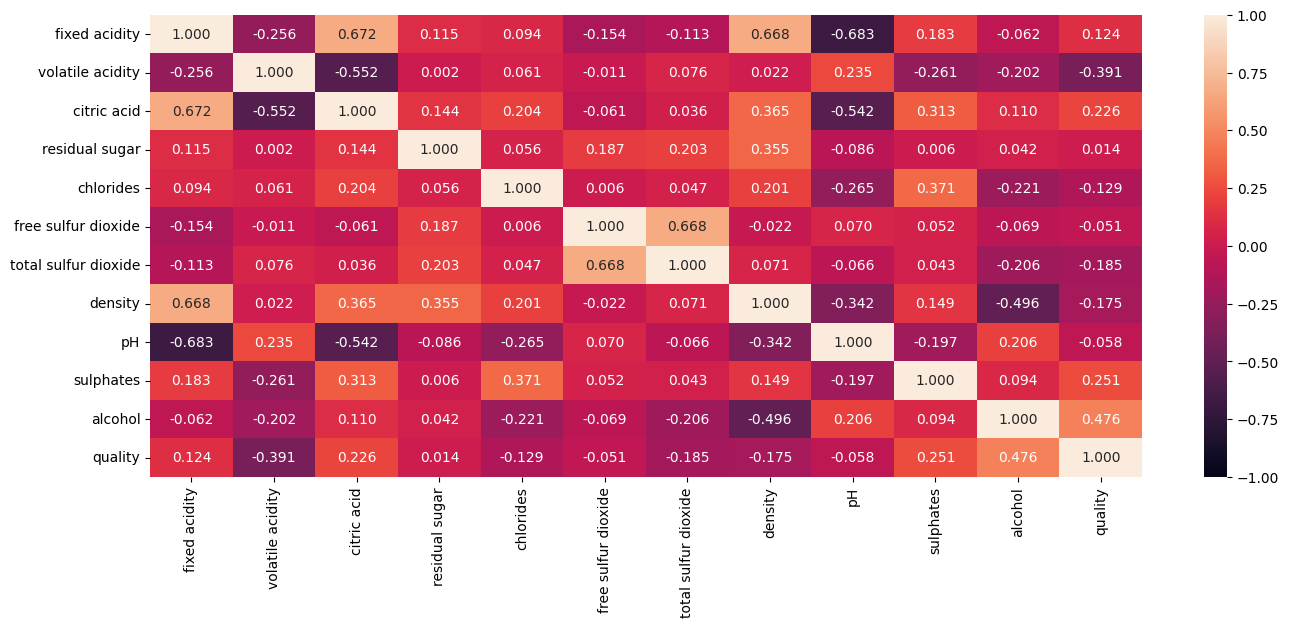

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

In [19]:
import numpy as np
np.triu(np.ones_like(corr), k=0)
np.triu(np.ones_like(corr), k=1)
np.tril(np.ones_like(corr), k=0)
np.tril(np.ones_like(corr), k=-1)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.]])

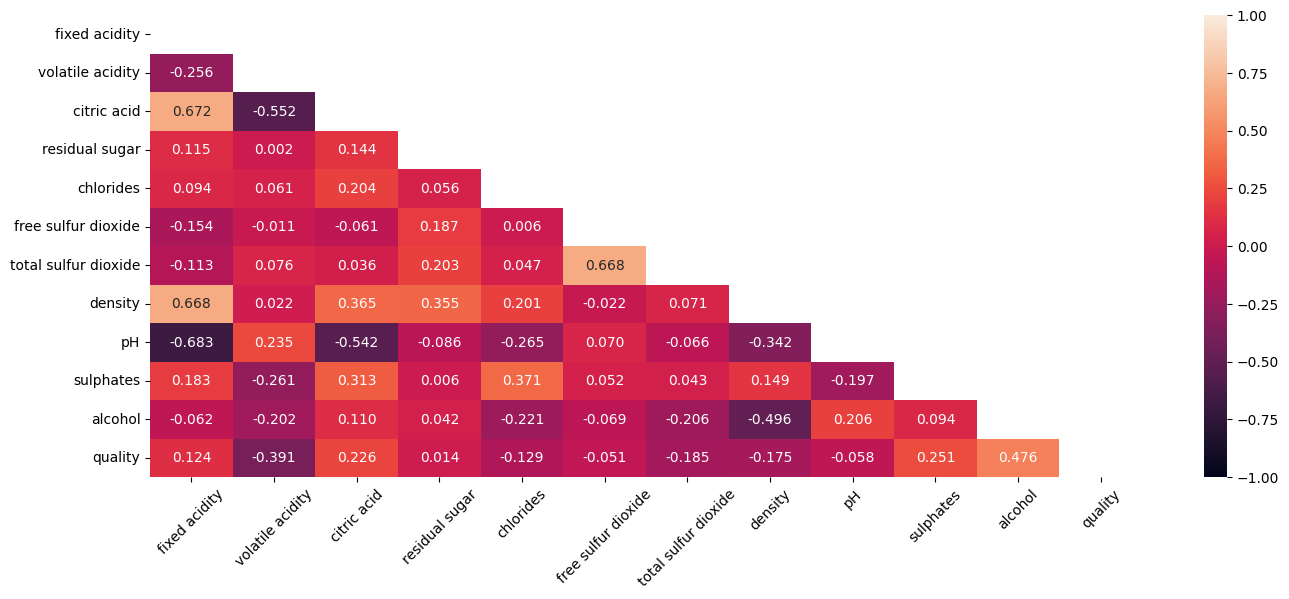

In [21]:
plt.figure(figsize=(16,6))
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1,mask=mask)
plt.xticks(rotation=45)
plt.show()

## 1-4 분류모델의 Feature importance


In [26]:
from sklearn.model_selection import train_test_split
x = redwine.iloc[:,:-1]
y = redwine.iloc[:,-1]
train_x, text_x, train_y, test_y = train_test_split(x,y,test_size=0.3)
train_x.shape, text_x.shape, train_y.shape, test_y.shape

((1119, 11), (480, 11), (1119,), (480,))

In [27]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10,
                                 random_state=10)
rf_model.fit

<bound method BaseForest.fit of RandomForestClassifier(n_estimators=10, random_state=10)>

In [28]:
rf_model.fit(train_x, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [29]:
train_x.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [32]:
rf_model.feature_importances_

array([0.0771067 , 0.10527669, 0.0773685 , 0.07800851, 0.07341267,
       0.06644649, 0.09877659, 0.07704285, 0.07243358, 0.1103127 ,
       0.16381473])

## importances를 이용한 변수 중요도 시각화

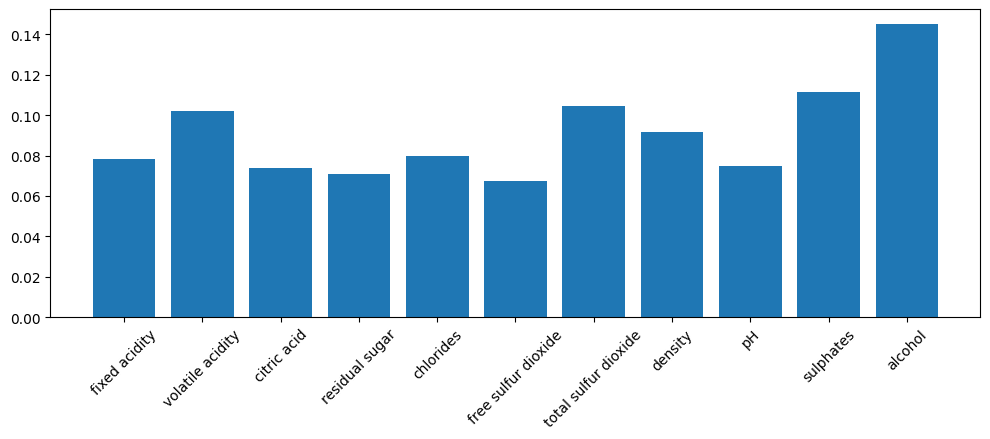

In [36]:
model = RandomForestClassifier()
model.fit(x, y)

# 특성 중요도 저장
features = pd.DataFrame({
    'feature': x.columns,
    'importance': model.feature_importances_
})

# 시각화
plt.figure(figsize=(12,4))
plt.bar(features.feature, features.importance)
plt.xticks(rotation=45, fontsize=10)
plt.show()

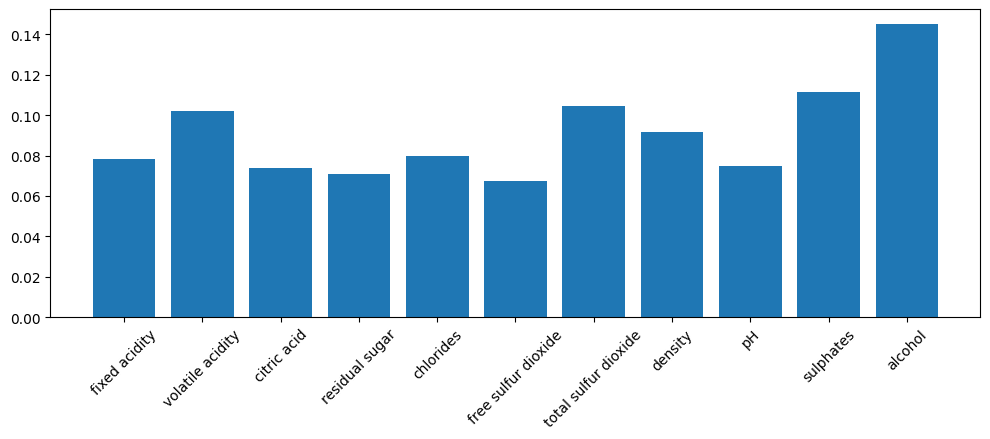

In [37]:
plt.figure(figsize=(12,4))
plt.bar(features.feature, features.importance)
plt.xticks(rotation=45, fontsize=10)
plt.show()

In [39]:
y_stack = features.importance.cumsum()


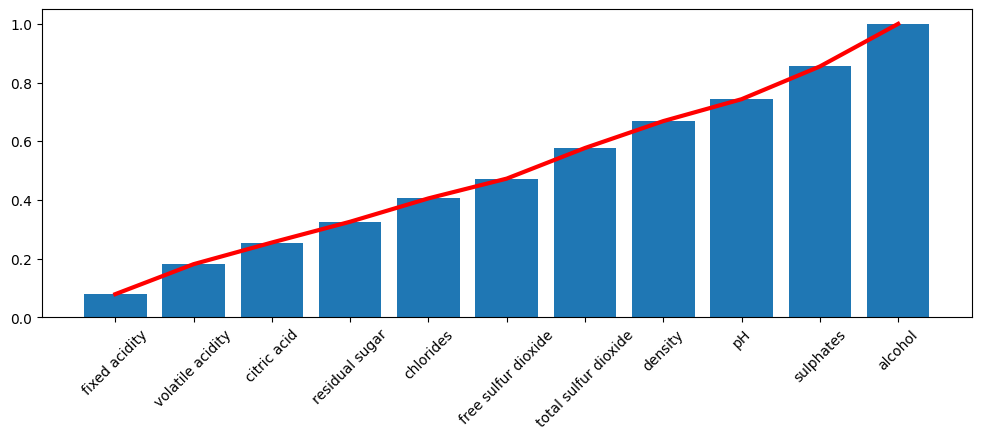

In [41]:
# 누적합을 이용해서 시각화
plt.figure(figsize=(12,4))
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, color='red', lw=3)
plt.xticks(rotation=45)  # ← 정확한 철자!

plt.show()

## RFE 방식
- rfe 클래스를 이용하면 중요도에 따라 낮은 변수부터 하나씩 제거해 가면서 최종 선택된 변수 개수만큼 중요도가 높은 변수를 찾음

In [42]:
from sklearn.feature_selection import RFE
rfe = RFE(rf_model,n_features_to_select=5)
rfe.fit(train_x, train_y)
rfe.get_support()

array([False,  True, False, False, False, False,  True,  True, False,
        True,  True])

In [43]:
features_rfe = pd.DataFrame(np.c_[x.columns, rfe.get_support()],
                           columns=['feature','selected'])
features_rfe[features_rfe.selected==True]

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True


## 1-5 selectkbest
 - 가장 높은 score 에 따라 k개 feature 선택

In [45]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
x = iris.iloc[:,:-1].values
y = iris.iloc[:,-1].values
x.shape, y.shape

((150, 4), (150,))

In [48]:
features_names = iris.columns[:-1].tolist()
features_names

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [49]:
x_new = SelectKBest(f_classif,
                   k=1
                   ).fit_transform(x,y)# 추출된 feature 갯수)
x_new[:3]

array([[1.4],
       [1.4],
       [1.3]])

# 2절, 파라미터 선택
- 하이퍼파라미터(사용자가 직접 설정할수 있는 파라미터)
- 1. validation_curve()
- 2. gridSearchCV()

In [52]:
# 데이터
from sklearn.datasets import load_digits
digits = load_digits()
# digits.data : (1797, 64) 배열 (독립변수)
# digits.images : (1797, 8, 8) 배열
# digits.target : 1797 열 배열 (타겟변수)
# digits.target_names : 타겟변수 내용
X, y = digits.data, digits.target
X.shape, y.shape

((1797, 64), (1797,))

In [53]:
X[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [54]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [55]:
np.all(X[0].reshape(8,8) == digits.images[0])

True

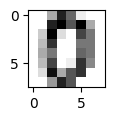

In [56]:

plt.figure(figsize=(1,1))
plt.imshow(X[0].reshape(8,8), cmap='gray_r')

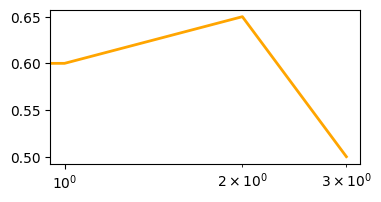

In [59]:
import matplotlib.pyplot as plt
range = np.array([0,1,2,3])
score = np.array([0.5,0.6,0.65,0.5])
plt.figure(figsize=(4,2))
plt.semilogx(range,score,color="orange", lw=2)

In [61]:
param_range = np.linspace(10e-6, 10e-1, 10)
param_range

array([1.0000e-05, 1.1112e-01, 2.2223e-01, 3.3334e-01, 4.4445e-01,
       5.5556e-01, 6.6667e-01, 7.7778e-01, 8.8889e-01, 1.0000e+00])

In [69]:
from sklearn.svm import SVC
model = SVC(probability=True) # probability=True:판별모형이라도 proba가능
model.fit(X, y)

SVC(probability=True)

In [70]:
%%time
from sklearn.model_selection import validation_curve
train_score, test_score = validation_curve(
    SVC(), # 예측모형
    X, y,
    param_name="gamma",
    param_range=param_range, # list로 파라미터 전달
    cv=10, # 교차검증 : 데이터 10개중 1개씩 test 데이터로 검증하고 평균 score
    scoring="accuracy",
    n_jobs=-1 # 시스템의 모든 core 사용
)

CPU times: total: 562 ms
Wall time: 28.6 s


In [81]:

test_score.shape, train_score.shape

((10, 10), (10, 10))

In [91]:
train_score_mean = np.mean(train_score, axis=1)
test_score_mean = np.mean(test_score, axis=1)
train_score_std = np.std(train_score, axis=1)
test_score_std = np.std(test_score, axis=1)

In [92]:

train_score_mean

array([0.92283445, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [93]:

test_score_mean

array([0.89925822, 0.10296089, 0.10184358, 0.10184358, 0.10184358,
       0.10184358, 0.10184358, 0.10184358, 0.12977654, 0.12977654])

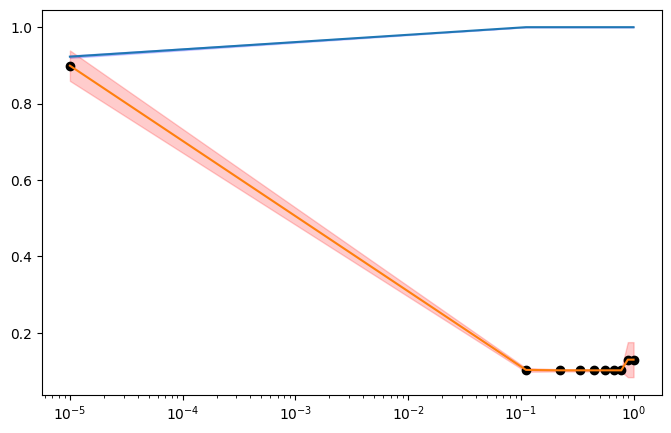

In [94]:
plt.figure(figsize=(8,5))
plt.semilogx(param_range, train_score_mean)
plt.fill_between(param_range, train_score_mean-train_score_std,
                train_score_mean+train_score_std,
                alpha=0.2,
                color='blue')
plt.semilogx(param_range, test_score_mean)
plt.fill_between(param_range, test_score_mean-test_score_std,
                test_score_mean+test_score_std,
                alpha=0.2,
                color='red')
plt.scatter(param_range, test_score_mean, c='k')

In [95]:
redwine = pd.read_csv('data/winequality-red.csv', sep=";")
redwine_x, redwine_y = redwine.iloc[:,:-1], redwine.iloc[:,-1]
redwine_x.shape, redwine_y.shape

((1599, 11), (1599,))

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.svm import SVC

# 데이터
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine_X, redwine_y = redwine.iloc[:, :-1], redwine.iloc[:, -1]
redwine_X.shape, redwine_y.shape

((1599, 11), (1599,))

In [100]:
%%time
# SelectKBest로 최적의 독립변수 k개 찾음 -> SVC()에서 최적의 C값을 찾음
selection = SelectKBest(k=1) # 가장 평가 점수가 높은 k개 찾음
svc = SVC(kernel='linear') # 직선으로 나누는 가장 단순한 분류모형
pipeline = Pipeline([('select', selection), ('svc', svc)])
param_grid = dict(select__k = [4,5,6,7,8,9,10,11],
        svc__C = [0.1, 1, 10] # 오차 범위 허용 정도(큰C:엄격, 작은C:허용범위 큼)
)
grid_search = GridSearchCV(
                pipeline,
                param_grid=param_grid, # 파라미터들
                cv=2,
                verbose=2, # 로그 출력의 수다스러운 정도
                n_jobs=-1
)
grid_search.fit(redwine_X.values, redwine_y.values)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
CPU times: total: 19.8 s
Wall time: 2min 57s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC(kernel='linear'))]),
             n_jobs=-1,
             param_grid={'select__k': [4, 5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10]},
             verbose=2)

## 자료 불균형 처리
- 단순 언더/오버 샘플링
- 단순 오버샘플링시 소수의 데이터를 복사하면 과적합 우려

In [102]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000,
                          n_features=10, # 독립변수 갯수
                          n_informative=5, # 타겟변수에 영향을 미치는 독립변수
                          n_redundant=0,
                          n_clusters_per_class=1,
                          n_classes=2,
                          weights=[0.99, 0.01], # 각 클래스에 할당된 표본 
                          random_state=42)
y.mean()

0.014

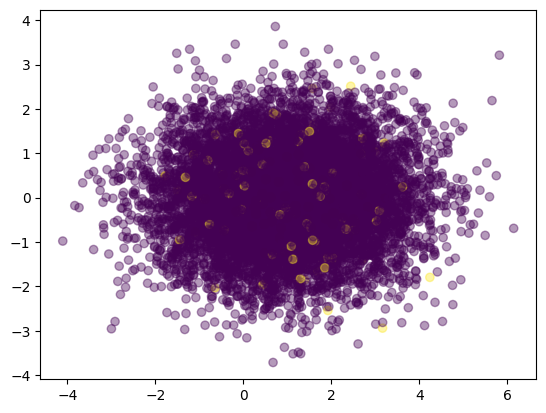

In [103]:
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.4)

In [104]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y,
                                                   random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7000, 10), (3000, 10), (7000,), (3000,))

In [105]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,
                                 max_features=2,
                                 random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [106]:
y_hat = rf_model.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(y_test, y_hat)

array([[2958,    0],
       [  34,    8]], dtype=int64)

In [107]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.19      0.32        42

    accuracy                           0.99      3000
   macro avg       0.99      0.60      0.66      3000
weighted avg       0.99      0.99      0.98      3000



## 3-2 SMOTE를 이용한 전체 오버샘플링 후 데이터 셋 분리
imbalanced-learn 라이브러리 install

In [108]:
# 0그룹과 1그룹의 갯수
df = pd.DataFrame(np.c_[X, y])
df.iloc[:,-1].value_counts()

0.0    9860
1.0     140
Name: 10, dtype: int64

In [111]:
from imblearn.over_sampling import SMOTE
sm = SMOTE() # 0그룹 : 1그룹 = 1:1
# sm = SMOTE(sampling_strategy={0:9860, 1:420})
X_resampled, y_resample = sm.fit_resample(X, y)
X_resampled.shape, y_resample.shape

((19720, 10), (19720,))

In [112]:
# 0그룹과 1그룹의 갯수
df = pd.DataFrame(np.c_[X_resampled, y_resample])
df.iloc[:,-1].value_counts()

0.0    9860
1.0    9860
Name: 10, dtype: int64

## 가중치 제어
- 자료 불균형 처리의 또다른 방법 

In [113]:
rf_model = RandomForestClassifier(n_estimators=100,
                                 max_features=2,
                                 random_state=42)

## 최종모형 탐색
- 목적 : 여러 분류 모형을 하나의 메타 분류모델로 연결하여서 개별 모형보다 더 좋은 일반화 성을 달성

## 배깅 알고리즘

In [124]:
wine_df = pd.read_csv('data/wine.csv')
wine_df.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [125]:
X = wine_df.iloc[:, 1:]
y = wine_df['Class label']
X.shape, y.shape

((178, 13), (178,))

In [126]:
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y,
                                                   random_state=1)

In [127]:
# 의사결정나무 알고리즘
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree_model.fit(train_X, train_y)
tree_model.score(test_X, test_y)

0.9074074074074074

In [128]:
# 배깅알고리즘
from sklearn.ensemble import BaggingClassifier
bag_model = BaggingClassifier(estimator=tree_model,
                 n_estimators=500,
                 bootstrap=True, #  복원추출을 허용
                 bootstrap_features=False, # 모든 feature 사용해서 학습
                 random_state=1)
bag_model.fit(train_X, train_y)
bag_model.score(test_X, test_y)

0.9629629629629629

In [130]:
tree_model = DecisionTreeClassifier()

In [131]:
# 배경 알고리즘
from sklearn.ensemble import BaggingClassifier
bag_model = BaggingClassifier(estimator=tree_model,
                             n_estimators=500,
                             bootstrap=True,)

In [129]:
# 랜던포레스트알고리즘
rf_model = RandomForestClassifier().fit(train_X, train_y)
rf_model.score(test_X, test_y)

1.0

In [ ]:
x, y = make_classification(n_samples=10000,
                           n_features=10,
                           n_informative=5,
                           n_redundant=
                                   

## 부스팅 알고리즘

In [132]:
from sklearn.ensemble import AdaBoostClassifier
model_measure(AdaBoostClassifier())

NameError: name 'model_measure' is not defined

In [ ]:
from xgboost import XGBClassifier
model_measure(XGBClassifier)